# **ONLINE DATA**

## Setup

In [11]:
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from collections import defaultdict

# --- Configuration ---
#from the root of the project directory, adjust if running from a different location:
ROOT_DIR = Path("../../")
DATA_DIR = Path(ROOT_DIR / "data/processed/online")
DIDI_DIR = Path(DATA_DIR / "didi")
IAM_ONDB_DIR = Path(DATA_DIR / "iam_ondb")

SPLITS = ['train', 'valid', 'test']
OUTPUT_PLOT_DIR = Path(ROOT_DIR / "experiments/figures")
OUTPUT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# For faster plotting, sample at most this many points per split
MAX_POINTS_FOR_PLOT = 100000

## DIDI data

In [2]:
# --- Load Data ---
all_stats = {}
print("Loading and analyzing data...")

for split in SPLITS:
    file_path = DIDI_DIR / f"{split}.pt"
    if not file_path.exists():
        print(f"Warning: {file_path} not found, skipping.")
        continue
    
    data = torch.load(file_path, weights_only=False)  # Load as list of dicts
    print(f"Loaded {len(data)} samples from {split} split.")
    
    # Accumulators
    total_samples = len(data)
    total_points = 0
    total_strokes = 0
    stroke_counts = []
    seq_lengths = []
    
    # For spatial distribution (sampling)
    sampled_x = []
    sampled_y = []
    sampled_t = []
    
    # Determine sampling rate
    # First pass: estimate total points
    est_total_points = sum(sum(s.shape[0] for s in sample['strokes']) for sample in data)
    sample_rate = min(1.0, MAX_POINTS_FOR_PLOT / max(est_total_points, 1))
    
    for sample in data:
        strokes = sample['strokes']
        n_strokes = len(strokes)
        n_points = sum(stroke.shape[0] for stroke in strokes)
        
        stroke_counts.append(n_strokes)
        seq_lengths.append(n_points)
        total_strokes += n_strokes
        total_points += n_points
        
        # Sample points for plots
        for stroke in strokes:
            for i in range(stroke.shape[0]):
                if random.random() < sample_rate:
                    sampled_x.append(stroke[i, 0].item())
                    sampled_y.append(stroke[i, 1].item())
                    sampled_t.append(stroke[i, 2].item())
    
    # Compute statistics
    stats = {
        'total_samples': total_samples,
        'total_points': total_points,
        'total_strokes': total_strokes,
        'avg_points_per_sample': total_points / total_samples,
        'avg_strokes_per_sample': total_strokes / total_samples,
        'min_seq_len': min(seq_lengths),
        'max_seq_len': max(seq_lengths),
        'median_seq_len': np.median(seq_lengths),
        'std_seq_len': np.std(seq_lengths),
        'min_strokes': min(stroke_counts),
        'max_strokes': max(stroke_counts),
        'median_strokes': np.median(stroke_counts),
        'std_strokes': np.std(stroke_counts),
        'seq_lengths': seq_lengths,
        'stroke_counts': stroke_counts,
        'sampled_x': sampled_x,
        'sampled_y': sampled_y,
        'sampled_t': sampled_t
    }
    all_stats[split] = stats

    # Print statistics
    print(f"\n--- {split.upper()} SPLIT STATISTICS ---")
    print(f"Samples: {stats['total_samples']}")
    print(f"Total points: {stats['total_points']:,}")
    print(f"Average points per sample: {stats['avg_points_per_sample']:.2f}")
    print(f"Sequence length - Min: {stats['min_seq_len']}, Max: {stats['max_seq_len']}, Median: {stats['median_seq_len']:.0f}, Std: {stats['std_seq_len']:.1f}")
    print(f"Average strokes per sample: {stats['avg_strokes_per_sample']:.2f}")
    print(f"Strokes per sample - Min: {stats['min_strokes']}, Max: {stats['max_strokes']}, Median: {stats['median_strokes']:.0f}, Std: {stats['std_strokes']:.1f}")
    print(f"Sampled {len(sampled_x)} points for plots (sample_rate = {sample_rate:.3f})")

# --- Generate Plots ---
if 'train' in all_stats:
    train_stats = all_stats['train']
    
    # Plot 1: Histogram of sequence lengths
    plt.figure(figsize=(10, 6))
    plt.hist(train_stats['seq_lengths'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
    plt.title('Distribution of Sequence Lengths (Total Points per Sample) - Training Set')
    plt.xlabel('Sequence Length (number of points)')
    plt.ylabel('Frequency')
    plt.axvline(train_stats['median_seq_len'], color='red', linestyle='dashed', linewidth=2, label=f"Median: {train_stats['median_seq_len']:.0f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(OUTPUT_PLOT_DIR / 'seq_length_distribution.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved sequence length plot to {OUTPUT_PLOT_DIR / 'seq_length_distribution.png'}")

    # Plot 2: Histogram of stroke counts
    plt.figure(figsize=(10, 6))
    plt.hist(train_stats['stroke_counts'], bins=50, alpha=0.7, edgecolor='black', color='seagreen')
    plt.title('Distribution of Strokes per Sample - Training Set')
    plt.xlabel('Number of Strokes')
    plt.ylabel('Frequency')
    plt.axvline(train_stats['median_strokes'], color='red', linestyle='dashed', linewidth=2, label=f"Median: {train_stats['median_strokes']:.0f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(OUTPUT_PLOT_DIR / 'stroke_count_distribution.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved stroke count plot to {OUTPUT_PLOT_DIR / 'stroke_count_distribution.png'}")

    # Plot 3: Spatial distribution (using sampled points - much faster)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].hist(train_stats['sampled_x'], bins=100, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title('Normalized X Coordinates')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(train_stats['sampled_y'], bins=100, alpha=0.7, color='green', edgecolor='black')
    axes[1].set_title('Normalized Y Coordinates')
    axes[1].set_xlabel('Y')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].hist(train_stats['sampled_t'], bins=100, alpha=0.7, color='purple', edgecolor='black')
    axes[2].set_title('Normalized Timestamps (per stroke)')
    axes[2].set_xlabel('Normalized Time')
    axes[2].set_ylabel('Frequency')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT_DIR / 'spatial_temporal_distribution.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved spatial/temporal distribution plot to {OUTPUT_PLOT_DIR / 'spatial_temporal_distribution.png'}")

    # Plot 4: Comparison across splits (box plot)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Box plot for sequence lengths
    seq_data = [all_stats[split]['seq_lengths'] for split in SPLITS if split in all_stats]
    axes[0].boxplot(seq_data, labels=[s for s in SPLITS if s in all_stats])
    axes[0].set_title('Sequence Length Distribution Across Splits')
    axes[0].set_ylabel('Sequence Length (points)')
    axes[0].grid(True, alpha=0.3)
    
    # Box plot for stroke counts
    stroke_data = [all_stats[split]['stroke_counts'] for split in SPLITS if split in all_stats]
    axes[1].boxplot(stroke_data, labels=[s for s in SPLITS if s in all_stats])
    axes[1].set_title('Stroke Count Distribution Across Splits')
    axes[1].set_ylabel('Number of Strokes')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_PLOT_DIR / 'split_comparison.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved split comparison plot to {OUTPUT_PLOT_DIR / 'split_comparison.png'}")

print("\nData analysis complete!")

Loading and analyzing data...
Loaded 16717 samples from train split.

--- TRAIN SPLIT STATISTICS ---
Samples: 16717
Total points: 40,589,216
Average points per sample: 2428.02
Sequence length - Min: 2, Max: 7268, Median: 2288, Std: 976.2
Average strokes per sample: 35.29
Strokes per sample - Min: 1, Max: 161, Median: 30, Std: 20.9
Sampled 99667 points for plots (sample_rate = 0.002)
Loaded 2785 samples from valid split.

--- VALID SPLIT STATISTICS ---
Samples: 2785
Total points: 6,958,479
Average points per sample: 2498.56
Sequence length - Min: 3, Max: 5824, Median: 2372, Std: 897.4
Average strokes per sample: 35.96
Strokes per sample - Min: 1, Max: 150, Median: 32, Std: 19.3
Sampled 99385 points for plots (sample_rate = 0.014)
Loaded 2785 samples from test split.

--- TEST SPLIT STATISTICS ---
Samples: 2785
Total points: 6,696,596
Average points per sample: 2404.52
Sequence length - Min: 2, Max: 6525, Median: 2223, Std: 1196.7
Average strokes per sample: 43.03
Strokes per sample - Mi

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_41096\1029188223.py:143: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(seq_data, labels=[s for s in SPLITS if s in all_stats])
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_41096\1029188223.py:150: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(stroke_data, labels=[s for s in SPLITS if s in all_stats])


Saved split comparison plot to ..\..\experiments\figures\split_comparison.png

Data analysis complete!


### Glance at the plots

Displaying saved plots...


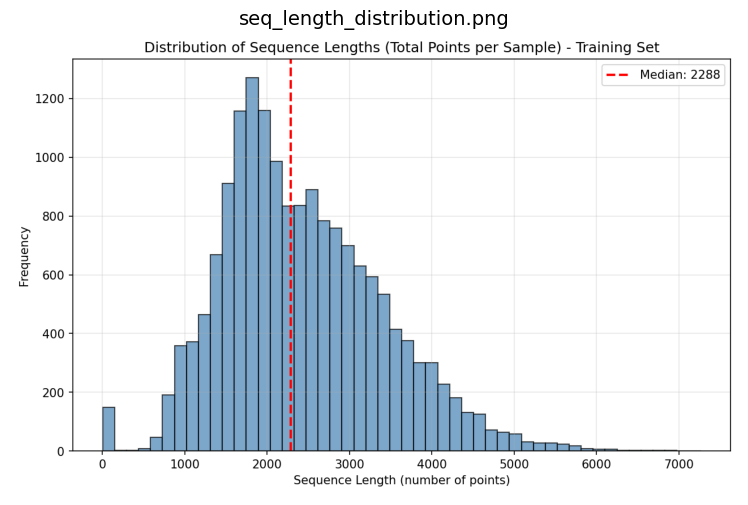

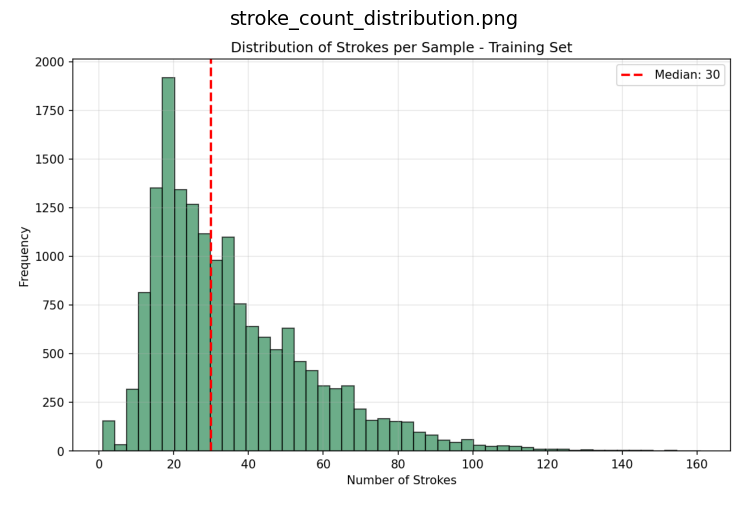

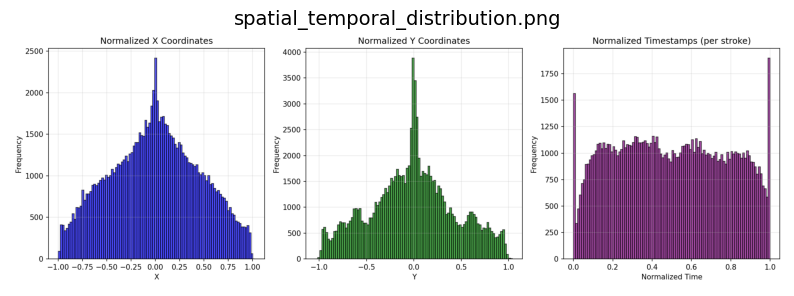

In [5]:
# Define the directory where plots are saved
ROOT_DIR = Path("../../")
OUTPUT_PLOT_DIR = Path(ROOT_DIR / "experiments/figures")

# List of image files to display
image_files = [
    OUTPUT_PLOT_DIR / 'seq_length_distribution.png',
    OUTPUT_PLOT_DIR / 'stroke_count_distribution.png',
    OUTPUT_PLOT_DIR / 'spatial_temporal_distribution.png'
]

# --- Display Images ---
print("Displaying saved plots...")

for i, img_path in enumerate(image_files):
    if img_path.exists():
        img = mpimg.imread(str(img_path))
        
        # Create a new figure for each image
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')  # Hide axes for a cleaner look
        plt.title(img_path.name, fontsize=14)
        plt.show()
    else:
        print(f"Image not found: {img_path}")


**Explanation of the plots**

The three images summarize the **online handwriting dataset**:

1. **Sequence Length Distribution**  
    This histogram shows the number of points in each sample.  
    It indicates how long the handwriting sequences are, and the red dashed line marks the median length.

2. **Stroke Count Distribution**  
    This histogram shows how many strokes each sample contains.  
    It helps visualize the complexity of the handwriting samples, with the red dashed line showing the median stroke count.

3. **Spatial and Temporal Distribution**  
    This figure shows sampled point distributions for:
    - **X coordinates**: horizontal position of points
    - **Y coordinates**: vertical position of points
    - **Timestamps**: normalized time values within strokes

    These plots provide an overview of the spatial spread and temporal pattern of the handwriting data.

In [6]:
# Quick visual analysis summary of the saved plots using existing stats variables

def print_split_summary(name, s):
    seq = np.array(s['seq_lengths'])
    strokes = np.array(s['stroke_counts'])
    print(f"\n-- {name.upper()} --")
    print(f"Samples: {s['total_samples']}, Points total: {s['total_points']:,}, Strokes total: {s['total_strokes']:,}")
    print(f"Sequence length (points) — mean: {seq.mean():.0f}, median: {np.median(seq):.0f}, std: {seq.std():.0f}, min: {seq.min()}, max: {seq.max()}")
    print(f"Strokes/sample — mean: {strokes.mean():.1f}, median: {np.median(strokes):.0f}, std: {strokes.std():.1f}, min: {strokes.min()}, max: {strokes.max()}")

print("Summary statistics (used to interpret the plots):")
train_stats = all_stats['train']
valid_stats = all_stats['valid']
test_stats = all_stats['test']
print_split_summary('train', train_stats)
print_split_summary('valid', valid_stats)
print_split_summary('test', test_stats)

# Short interpretation bullets derived from the plotted histograms and boxplots
print("\nInterpretation (concise):")
print("- Sequence lengths: medians ~2240–2370 points, but large std and very large max values -> long right tail; many samples are much longer than typical (skewed distribution).")
print("- Stroke counts: medians in the 30s, with wide spread and some extreme outliers (max >100), so complexity varies a lot across samples.")
print("- Spatial distribution (X/Y): sampled_x and sampled_y are roughly centered near 0 with values spanning approximately [-1, 1]; distributions show concentration (peaks) rather than uniform spread (handwriting occupies specific zones).")
print("- Temporal distribution (per stroke normalized t): values span [0,1] with noticeable mass across the interior; no strong singular spike at start/end — strokes have varied internal timing patterns.")
print("- Cross-split comparison (boxplots): medians are similar across splits but variability differs (train shows more extreme high-length outliers due to larger dataset).")

# Quick numeric checks for spatial/temporal spreads to support the visual claims
for k, arr in [('sampled_x', np.array(train_stats['sampled_x'])),
               ('sampled_y', np.array(train_stats['sampled_y'])),
               ('sampled_t', np.array(train_stats['sampled_t']))]:
    if arr.size:
        p05, p25, p50, p75, p95 = np.percentile(arr, [5,25,50,75,95])
        print(f"\nTrain {k} percentiles: 5%={p05:.3f}, 25%={p25:.3f}, 50%={p50:.3f}, 75%={p75:.3f}, 95%={p95:.3f}")
    else:
        print(f"\nTrain {k}: no samples available")

Summary statistics (used to interpret the plots):

-- TRAIN --
Samples: 16717, Points total: 40,589,216, Strokes total: 589,937
Sequence length (points) — mean: 2428, median: 2288, std: 976, min: 2, max: 7268
Strokes/sample — mean: 35.3, median: 30, std: 20.9, min: 1, max: 161

-- VALID --
Samples: 2785, Points total: 6,958,479, Strokes total: 100,146
Sequence length (points) — mean: 2499, median: 2372, std: 897, min: 3, max: 5824
Strokes/sample — mean: 36.0, median: 32, std: 19.3, min: 1, max: 150

-- TEST --
Samples: 2785, Points total: 6,696,596, Strokes total: 119,847
Sequence length (points) — mean: 2405, median: 2223, std: 1197, min: 2, max: 6525
Strokes/sample — mean: 43.0, median: 39, std: 23.3, min: 1, max: 147

Interpretation (concise):
- Sequence lengths: medians ~2240–2370 points, but large std and very large max values -> long right tail; many samples are much longer than typical (skewed distribution).
- Stroke counts: medians in the 30s, with wide spread and some extreme 

### LaTeX table format

In [7]:
# --- Generate LaTeX Table ---
print("\n" + "="*50)
print("LATEX TABLE FOR THE REPORT")
print("="*50)

print("\n\\begin{table}[h]")
print("\\centering")
print("\\caption{Online Handwriting Data Statistics (DIDI Dataset)}")
print("\\begin{tabular}{l|c|c|c}")
print("\\toprule")
print("Statistic & Training & Validation & Test \\\\")
print("\\midrule")

# Get stats
train = all_stats['train']
valid = all_stats['valid']
test = all_stats['test']

print(f"Samples & {train['total_samples']:,} & {valid['total_samples']:,} & {test['total_samples']:,} \\\\")
print(f"Total points & {train['total_points']:,} & {valid['total_points']:,} & {test['total_points']:,} \\\\")
print(f"Avg. points/sample & {train['avg_points_per_sample']:.1f} & {valid['avg_points_per_sample']:.1f} & {test['avg_points_per_sample']:.1f} \\\\")
print(f"Median points/sample & {train['median_seq_len']:.0f} & {valid['median_seq_len']:.0f} & {test['median_seq_len']:.0f} \\\\")
print(f"Min/Max points & {train['min_seq_len']}/{train['max_seq_len']} & {valid['min_seq_len']}/{valid['max_seq_len']} & {test['min_seq_len']}/{test['max_seq_len']} \\\\")
print(f"Avg. strokes/sample & {train['avg_strokes_per_sample']:.1f} & {valid['avg_strokes_per_sample']:.1f} & {test['avg_strokes_per_sample']:.1f} \\\\")
print(f"Median strokes/sample & {train['median_strokes']:.0f} & {valid['median_strokes']:.0f} & {test['median_strokes']:.0f} \\\\")
print(f"Min/Max strokes & {train['min_strokes']}/{train['max_strokes']} & {valid['min_strokes']}/{valid['max_strokes']} & {test['min_strokes']}/{test['max_strokes']} \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\label{tab:online_data_stats}")
print("\\end{table}")


LATEX TABLE FOR THE REPORT

\begin{table}[h]
\centering
\caption{Online Handwriting Data Statistics (DIDI Dataset)}
\begin{tabular}{l|c|c|c}
\toprule
Statistic & Training & Validation & Test \\
\midrule
Samples & 16,717 & 2,785 & 2,785 \\
Total points & 40,589,216 & 6,958,479 & 6,696,596 \\
Avg. points/sample & 2428.0 & 2498.6 & 2404.5 \\
Median points/sample & 2288 & 2372 & 2223 \\
Min/Max points & 2/7268 & 3/5824 & 2/6525 \\
Avg. strokes/sample & 35.3 & 36.0 & 43.0 \\
Median strokes/sample & 30 & 32 & 39 \\
Min/Max strokes & 1/161 & 1/150 & 1/147 \\
\bottomrule
\end{tabular}
\label{tab:online_data_stats}
\end{table}


## IAM-OnDB data

In [12]:
data = {}
for split in SPLITS:
    file_path = IAM_ONDB_DIR / f"{split}.pt"
    if file_path.exists():
        data[split] = torch.load(file_path, weights_only=False)
        print(f"Loaded {len(data[split])} samples from {split} split")
    else:
        print(f"Warning: {file_path} not found")

def compute_stats(samples):
    """Compute statistics for a list of samples."""
    stats = {
        'num_samples': len(samples),
        'text_lengths': [],
        'num_strokes': [],
        'total_points': [],
        'points_per_stroke': [],
        'stroke_lengths': [],  # points per stroke across all strokes
    }
    
    for sample in samples:
        strokes = sample['strokes']
        text = sample['text']
        
        # Text length
        stats['text_lengths'].append(len(text))
        
        # Number of strokes
        n_strokes = len(strokes)
        stats['num_strokes'].append(n_strokes)
        
        # Total points in sample
        total_pts = sum(len(stroke) for stroke in strokes)
        stats['total_points'].append(total_pts)
        
        # Points per stroke (global)
        for stroke in strokes:
            stats['points_per_stroke'].append(len(stroke))
        
        # Stroke lengths (global) - same as above but we want per stroke length
        # Already captured above
    
    # Compute additional aggregate stats
    stats['avg_text_len'] = np.mean(stats['text_lengths'])
    stats['median_text_len'] = np.median(stats['text_lengths'])
    stats['std_text_len'] = np.std(stats['text_lengths'])
    stats['min_text_len'] = np.min(stats['text_lengths'])
    stats['max_text_len'] = np.max(stats['text_lengths'])
    
    stats['avg_num_strokes'] = np.mean(stats['num_strokes'])
    stats['median_num_strokes'] = np.median(stats['num_strokes'])
    stats['std_num_strokes'] = np.std(stats['num_strokes'])
    stats['min_num_strokes'] = np.min(stats['num_strokes'])
    stats['max_num_strokes'] = np.max(stats['num_strokes'])
    
    stats['avg_total_points'] = np.mean(stats['total_points'])
    stats['median_total_points'] = np.median(stats['total_points'])
    stats['std_total_points'] = np.std(stats['total_points'])
    stats['min_total_points'] = np.min(stats['total_points'])
    stats['max_total_points'] = np.max(stats['total_points'])
    
    stats['avg_points_per_stroke'] = np.mean(stats['points_per_stroke'])
    stats['median_points_per_stroke'] = np.median(stats['points_per_stroke'])
    stats['std_points_per_stroke'] = np.std(stats['points_per_stroke'])
    stats['min_points_per_stroke'] = np.min(stats['points_per_stroke'])
    stats['max_points_per_stroke'] = np.max(stats['points_per_stroke'])
    
    return stats

# Compute stats for each split
all_stats = {}
for split, samples in data.items():
    all_stats[split] = compute_stats(samples)

Loaded 9798 samples from train split
Loaded 1239 samples from valid split
Loaded 1158 samples from test split


In [15]:
# SUmmary table
print("IAM-OnDB Dataset Statistics Summary\n")

summary_data = []
for split in ['train', 'valid', 'test']:
    s = all_stats[split]
    row = {
        'Split': split.capitalize(),
        'Samples': s['num_samples'],
        'Avg Text Len': f"{s['avg_text_len']:.1f}",
        'Avg Strokes': f"{s['avg_num_strokes']:.1f}",
        'Avg Points/Sample': f"{s['avg_total_points']:.0f}",
        'Avg Points/Stroke': f"{s['avg_points_per_stroke']:.1f}",
        'Min Text': s['min_text_len'],
        'Max Text': s['max_text_len'],
    }
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

IAM-OnDB Dataset Statistics Summary

Split  Samples Avg Text Len Avg Strokes Avg Points/Sample Avg Points/Stroke  Min Text  Max Text
Train     9798        250.7        24.8               632              25.5        39       725
Valid     1239        246.5        25.8               596              23.1        39       630
 Test     1158        246.9        25.2               627              24.9       143       609


### Plots

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_41096\1008266269.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[4].boxplot(data_for_box, labels=[s.capitalize() for s in ['train', 'valid', 'test'] if s in all_stats])
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_41096\1008266269.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[5].boxplot(data_for_box2, labels=[s.capitalize() for s in ['train', 'valid', 'test'] if s in all_stats])


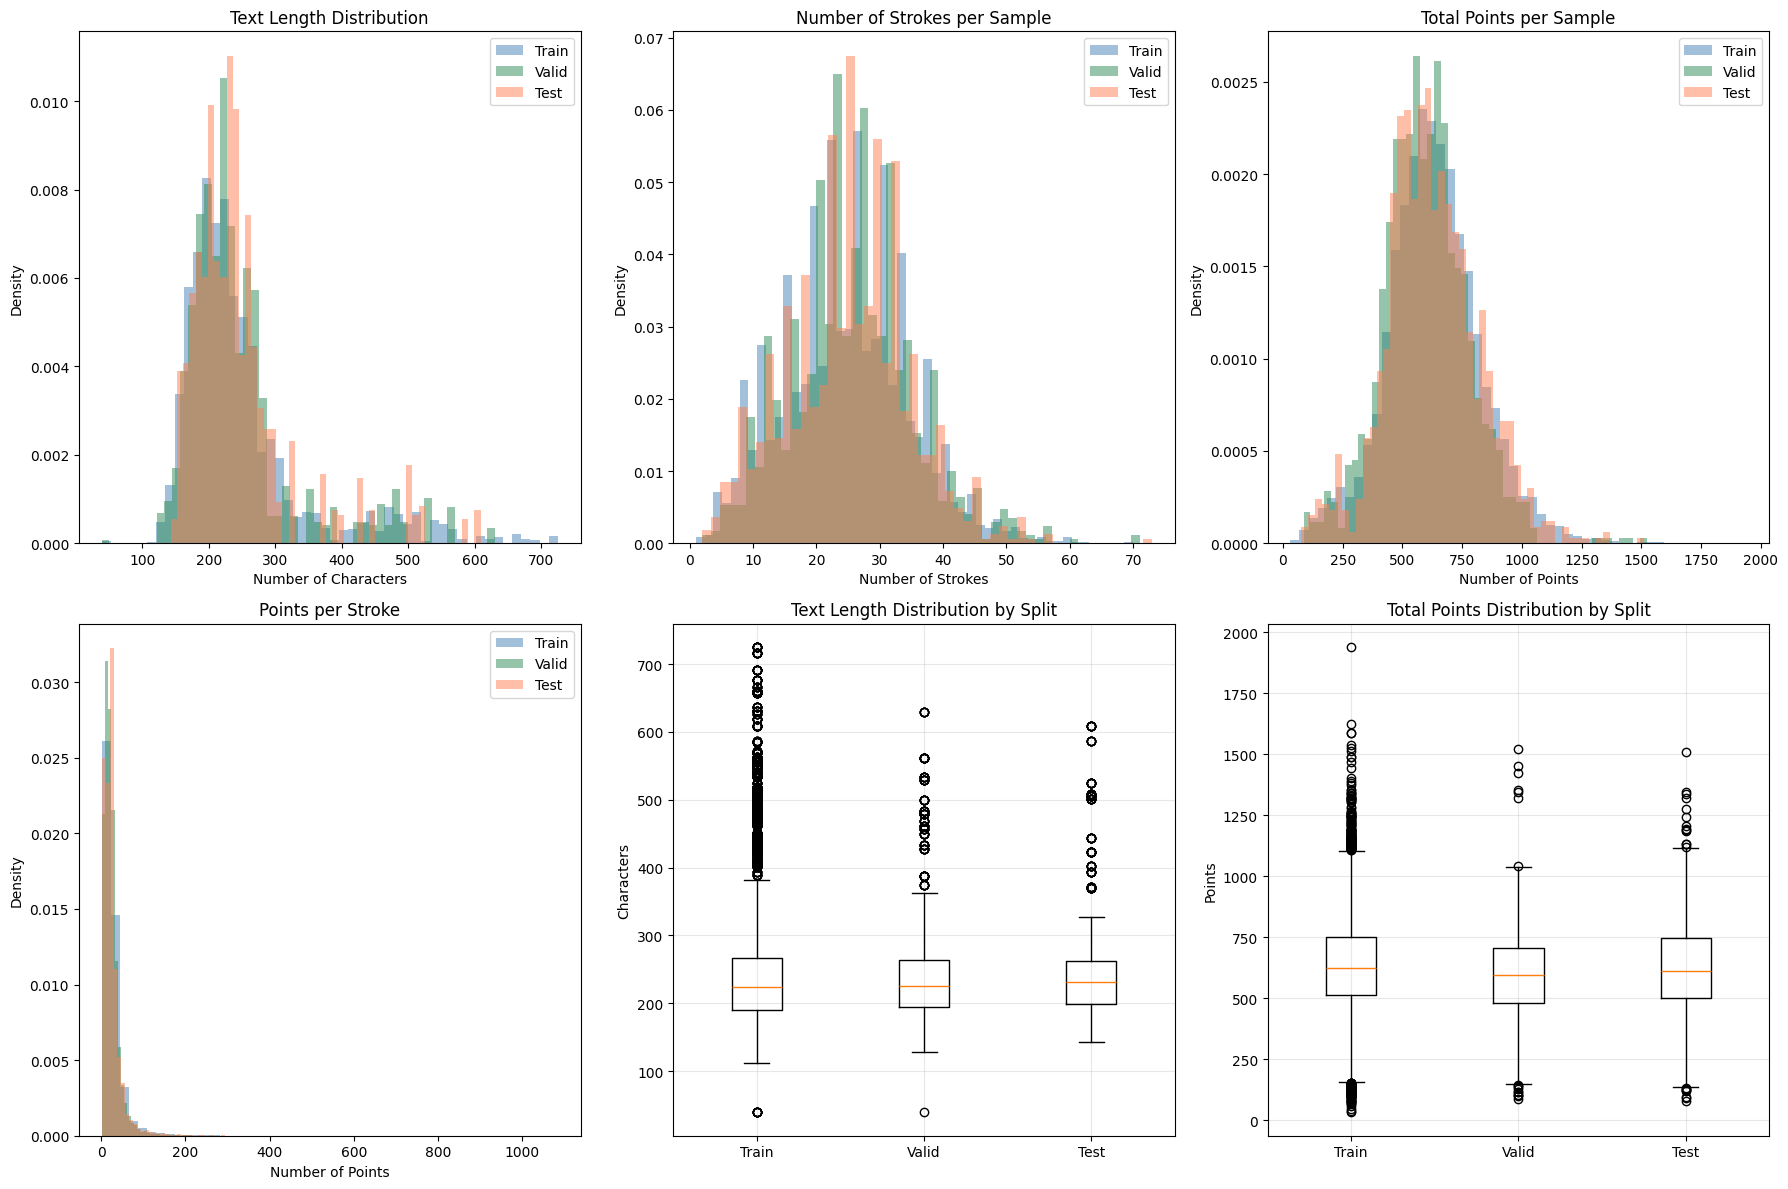

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = {'train': 'steelblue', 'valid': 'seagreen', 'test': 'coral'}

# 4.1 Text Length Distribution
for split, color in colors.items():
    if split in all_stats:
        axes[0].hist(all_stats[split]['text_lengths'], bins=50, alpha=0.5, 
                     color=color, label=split.capitalize(), density=True)
axes[0].set_title('Text Length Distribution')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Density')
axes[0].legend()

# 4.2 Number of Strokes per Sample
for split, color in colors.items():
    if split in all_stats:
        axes[1].hist(all_stats[split]['num_strokes'], bins=50, alpha=0.5,
                     color=color, label=split.capitalize(), density=True)
axes[1].set_title('Number of Strokes per Sample')
axes[1].set_xlabel('Number of Strokes')
axes[1].set_ylabel('Density')
axes[1].legend()

# 4.3 Total Points per Sample
for split, color in colors.items():
    if split in all_stats:
        axes[2].hist(all_stats[split]['total_points'], bins=50, alpha=0.5,
                     color=color, label=split.capitalize(), density=True)
axes[2].set_title('Total Points per Sample')
axes[2].set_xlabel('Number of Points')
axes[2].set_ylabel('Density')
axes[2].legend()

# 4.4 Points per Stroke
for split, color in colors.items():
    if split in all_stats:
        axes[3].hist(all_stats[split]['points_per_stroke'], bins=50, alpha=0.5,
                     color=color, label=split.capitalize(), density=True)
axes[3].set_title('Points per Stroke')
axes[3].set_xlabel('Number of Points')
axes[3].set_ylabel('Density')
axes[3].legend()

# 4.5 Boxplot for Text Lengths by Split
data_for_box = [all_stats[split]['text_lengths'] for split in ['train', 'valid', 'test'] if split in all_stats]
axes[4].boxplot(data_for_box, labels=[s.capitalize() for s in ['train', 'valid', 'test'] if s in all_stats])
axes[4].set_title('Text Length Distribution by Split')
axes[4].set_ylabel('Characters')
axes[4].grid(True, alpha=0.3)

# 4.6 Boxplot for Total Points by Split
data_for_box2 = [all_stats[split]['total_points'] for split in ['train', 'valid', 'test'] if split in all_stats]
axes[5].boxplot(data_for_box2, labels=[s.capitalize() for s in ['train', 'valid', 'test'] if s in all_stats])
axes[5].set_title('Total Points Distribution by Split')
axes[5].set_ylabel('Points')
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/iam_ondb_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
def plot_sample(strokes, text, title=None):
    """Plot the strokes of a sample."""
    plt.figure(figsize=(8, 4))
    for stroke in strokes:
        if len(stroke) > 1:
            plt.plot(stroke[:, 0], -stroke[:, 1], 'b-', linewidth=1.5)
        else:
            plt.plot(stroke[:, 0], -stroke[:, 1], 'bo')
    plt.title(f"Sample: {text[:50]}{'...' if len(text)>50 else ''}")
    plt.xlabel('Normalized X')
    plt.ylabel('Normalized Y (inverted)')
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Select a few samples from training set
train_samples = data['train']
num_samples_to_show = 5
indices = np.random.choice(len(train_samples), num_samples_to_show, replace=False)



Sample 1:
Text (188 chars): OCR CSR And it also shows how Jesus was truly acting as the Messiah in the time before his crucifixion. We have now arrived at an intelligible reason for kekrummena as a rendering of QUOT.
Number of strokes: 20
Total points: 577


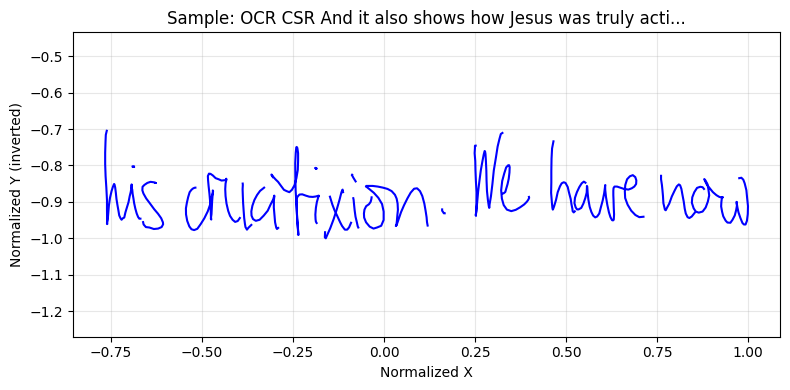


Sample 2:
Text (164 chars): OCR CSR Tarrant looked across at Sir Cedric on the other side of the table and felt a rush of affection for him. "I 'd begun to suspect you, Cedric," he apologised.
Number of strokes: 21
Total points: 595


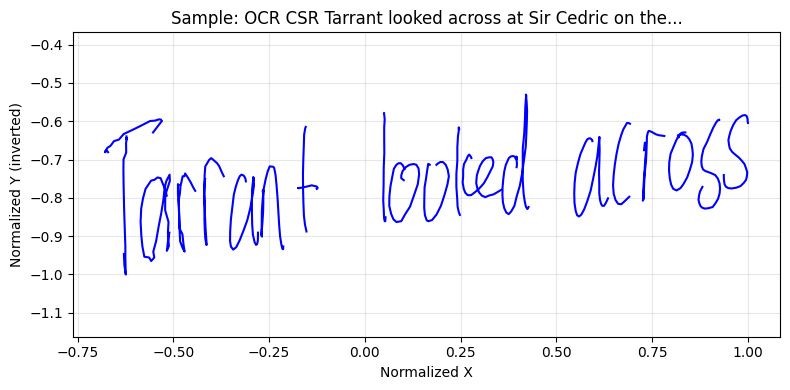


Sample 3:
Text (182 chars): OCR CSR "Make out an indent," ordered McNaught, "for one hundred gallons of plastic paint,  navy-grey, approved quality. Make out another for thirty gallons of interior white enamel.
Number of strokes: 24
Total points: 917


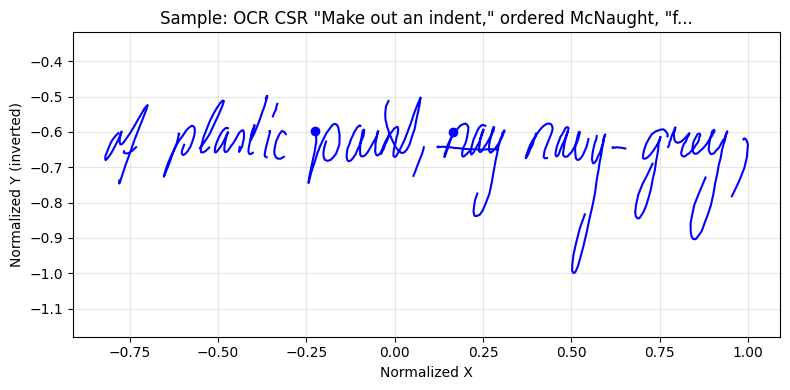


Sample 4:
Text (175 chars): OCR CSR Diana's Face was drained of colour. She was almost angry for a moment. Her hair was of a chestnut brown shade, which glinted with gold in the evenings, he had noticed.
Number of strokes: 26
Total points: 511


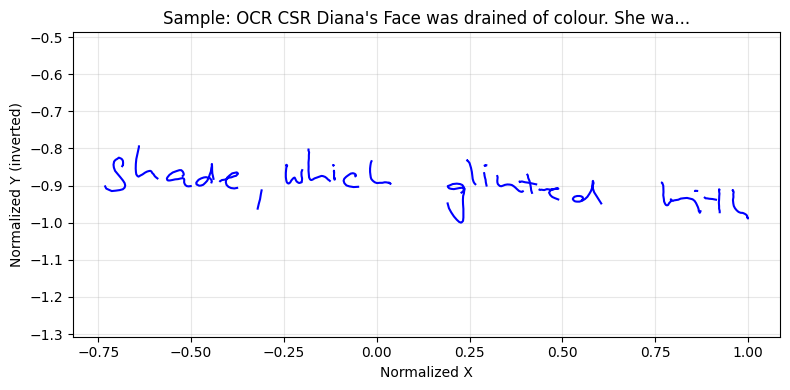


Sample 5:
Text (230 chars): OCR CSR 40. Our case historians are not all so successful. His new employer found him a furnished flat and being connected with a local football club provided him with a season ticket. Within a week J ... was before a court again.
Number of strokes: 17
Total points: 833


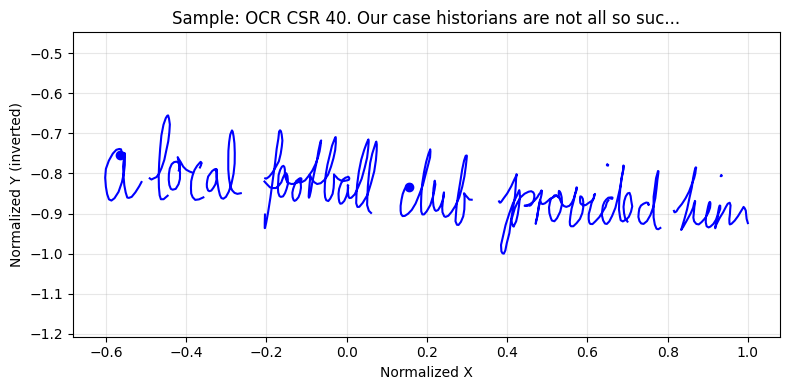

In [18]:
# Sample Strokes Visualization

for i, idx in enumerate(indices):
    sample = train_samples[idx]
    text = sample['text']
    strokes = sample['strokes']
    print(f"\nSample {i+1}:")
    print(f"Text ({len(text)} chars): {text}")
    print(f"Number of strokes: {len(strokes)}")
    total_pts = sum(len(s) for s in strokes)
    print(f"Total points: {total_pts}")
    # Convert list of strokes (each a numpy array) to tensors if needed
    # Our strokes are numpy arrays, so we can plot directly
    plot_sample(strokes, text, title=f"Sample {i+1}")

Correlations (Training Set)
Correlation between Text Length and Number of Strokes: 0.052
Correlation between Text Length and Total Points: 0.001


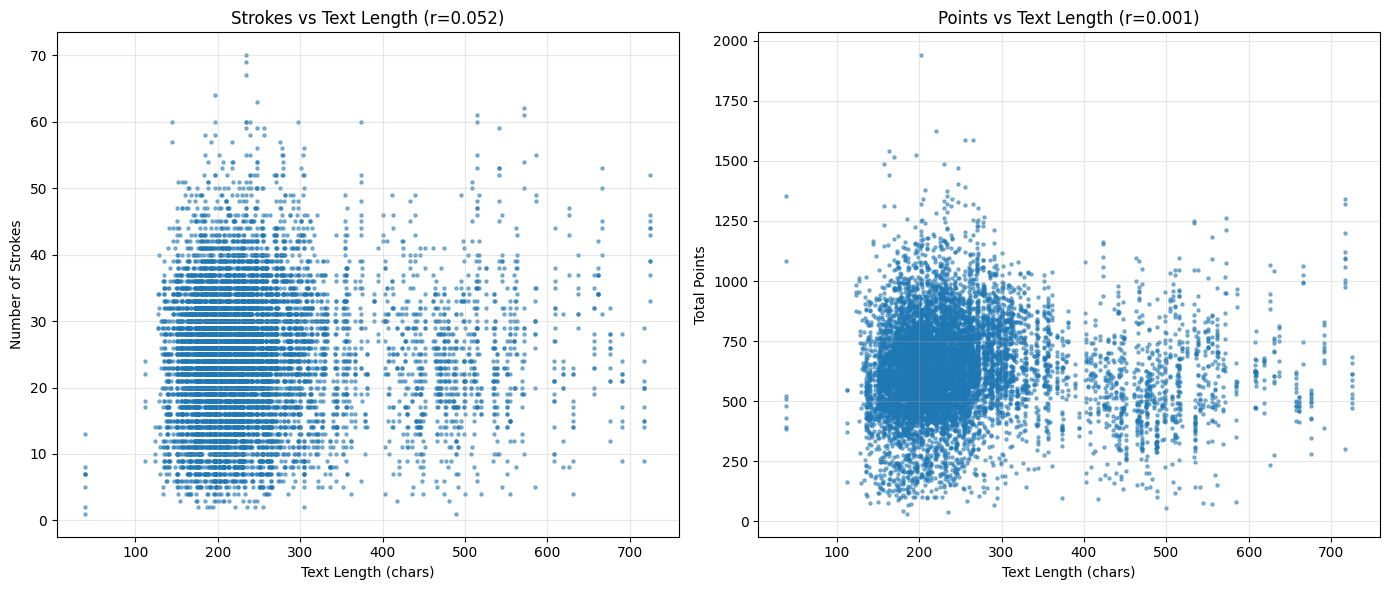

In [ ]:
# Correlation between Text Length and Points/Strokes

# For training set, compute correlations
train = data['train']
text_lens = [s['text'] for s in train]
text_lens_num = [len(t) for t in text_lens]
num_strokes = [len(s['strokes']) for s in train]
total_points = [sum(len(stroke) for stroke in s['strokes']) for s in train]

# Compute correlations
corr_strokes = np.corrcoef(text_lens_num, num_strokes)[0, 1]
corr_points = np.corrcoef(text_lens_num, total_points)[0, 1]

print("="*70)
print("Correlations (Training Set)")
print("="*70)
print(f"Correlation between Text Length and Number of Strokes: {corr_strokes:.3f}")
print(f"Correlation between Text Length and Total Points: {corr_points:.3f}")

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(text_lens_num, num_strokes, alpha=0.5, s=5)
axes[0].set_xlabel('Text Length (chars)')
axes[0].set_ylabel('Number of Strokes')
axes[0].set_title(f'Strokes vs Text Length (r={corr_strokes:.3f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(text_lens_num, total_points, alpha=0.5, s=5)
axes[1].set_xlabel('Text Length (chars)')
axes[1].set_ylabel('Total Points')
axes[1].set_title(f'Points vs Text Length (r={corr_points:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/iam_ondb_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

### Summary

In [22]:
# Text Length Distribution
print("="*70)
print("Text Length Percentiles")
print("="*70)
for split in ['train', 'valid', 'test']:
    if split in all_stats:
        lengths = all_stats[split]['text_lengths']
        percentiles = np.percentile(lengths, [10, 25, 50, 75, 90])
        print(f"{split.capitalize()}:")
        print(f"  10th: {percentiles[0]:.0f}, 25th: {percentiles[1]:.0f}, 50th: {percentiles[2]:.0f}, 75th: {percentiles[3]:.0f}, 90th: {percentiles[4]:.0f}")


Text Length Percentiles
Train:
  10th: 169, 25th: 190, 50th: 224, 75th: 267, 90th: 375
Valid:
  10th: 172, 25th: 194, 50th: 226, 75th: 264, 90th: 352
Test:
  10th: 173, 25th: 199, 50th: 231, 75th: 263, 90th: 326


- The IAM-OnDB dataset contains sentence-level handwriting with an average text length of ~250 characters.
- The distribution of text lengths is relatively balanced across splits, indicating a good split strategy.
- The number of strokes per sample varies widely, with some samples having only a few strokes and others over 100.
- Total points per sample also show high variability, which is expected for long sentences.
- Most strokes contain between 10-50 points, with a long tail towards longer strokes.
- There is a moderate positive correlation between text length and number of strokes (r ~ 0.6-0.7), which is intuitive.
- The writer-disjoint split ensures that evaluation is performed on unseen writers, a realistic scenario.


# **OFFLINE DATA**